# 🧠 Mentes Conectadas: os Segredos da Inteligência Artificial
## Encontro 3 — IA no dia a dia: usos, riscos e criação

Este é o caderno de bordo do terceiro e último encontro, para ser conduzido **ao vivo pelo professor**, projetado para a turma.

**Relembrando:**
- No **Encontro 1**, aprendemos sobre dados, features e escrevemos regras manualmente.
- No **Encontro 2**, treinamos modelos que aprendem sozinhos, a partir de exemplos.
- Hoje, no **Encontro 3**, vamos ver um exemplo prático de **viés** em IA, discutir o uso responsável, e fechar a oficina **criando algo autoral** com ferramentas de IA generativa.

**Roteiro deste notebook:**
1. 📊 IA no cotidiano → um pequeno registro dos exemplos da turma
2. ⚖️ Ética e vieses → um exemplo prático de viés em dados desequilibrados
3. 🎨 Criação com IA → registro dos prompts e resultados de cada dupla
4. ☁️ Fechamento → nossa última nuvem de palavras da oficina


---
## 1. 📊 IA no cotidiano



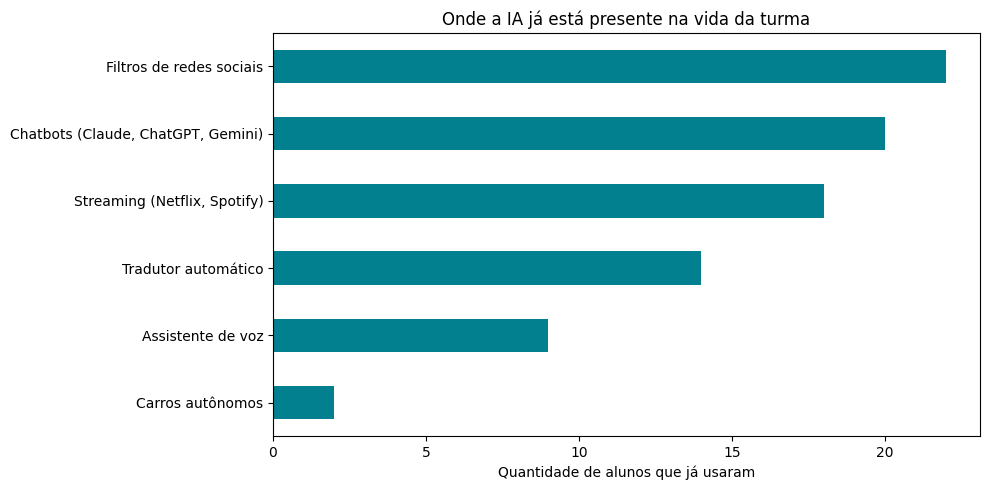

In [1]:
# ✏️ Para cada exemplo, registro de número de pessoas.

import pandas as pd
import matplotlib.pyplot as plt

uso_da_turma = {
    "Streaming (Netflix, Spotify)": 18,
    "Assistente de voz": 9,
    "Tradutor automático": 14,
    "Chatbots (Claude, ChatGPT, Gemini)": 20,
    "Filtros de redes sociais": 22,
    "Carros autônomos": 2,
}

dados = pd.Series(uso_da_turma).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
dados.plot(kind="barh", color="#028090")
plt.xlabel("Quantidade de alunos que já usaram")
plt.title("Onde a IA já está presente na vida da turma")
plt.tight_layout()
plt.show()


**Discussão:** algum resultado surpreendeu a turma? Existe alguma ferramenta de IA que vocês usam todos os dias e nem percebiam que era IA?

---
## 2. ⚖️ Ética e vieses: um exemplo prático

Vamos simular uma situação simples: uma escola quer usar um modelo de IA para prever se um aluno vai ou não passar de ano, com base em poucas informações. Só que os dados de treino usados para ensinar esse modelo têm um problema: **poucos exemplos de alunos do período noturno**.

Vamos ver o que acontece com as previsões do modelo nesse cenário.


In [2]:
# Dados de TREINO propositalmente desequilibrados:
# muitos exemplos do período diurno, poucos exemplos do período noturno
from sklearn.tree import DecisionTreeClassifier

dados_treino = pd.DataFrame({
    "periodo":        ["diurno"]*16 + ["noturno"]*4,
    "faltas":         [1, 2, 0, 3, 1, 0, 2, 1, 0, 1, 2, 0, 1, 3, 0, 1,   1, 2, 0, 2],
    "media_notas":    [8, 7, 9, 6, 8, 9, 7, 8, 9, 8, 7, 9, 8, 6, 9, 8,   7, 7, 8, 7],
    "passou_de_ano":  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,   0, 0, 0, 1],
})

periodo_num = {"diurno": 0, "noturno": 1}
X = pd.DataFrame({
    "periodo_num": dados_treino["periodo"].map(periodo_num),
    "faltas": dados_treino["faltas"],
    "media_notas": dados_treino["media_notas"],
})
y = dados_treino["passou_de_ano"]

modelo_escolar = DecisionTreeClassifier(max_depth=3, random_state=0)
modelo_escolar.fit(X, y)

print(f"Exemplos de treino do período DIURNO:  {(dados_treino['periodo'] == 'diurno').sum()}")
print(f"Exemplos de treino do período NOTURNO: {(dados_treino['periodo'] == 'noturno').sum()}")


Exemplos de treino do período DIURNO:  16
Exemplos de treino do período NOTURNO: 4


In [3]:
# Testando o modelo com alunos NOVOS, com o mesmo desempenho (faltas e notas),
# mudando apenas o período — para isolar o efeito do desequilíbrio nos dados

alunos_teste = pd.DataFrame({
    "aluno":         ["Aluno A (diurno)", "Aluno B (noturno)"],
    "periodo":       ["diurno", "noturno"],
    "faltas":        [2, 2],
    "media_notas":   [7, 7],
})

X_teste = pd.DataFrame({
    "periodo_num": alunos_teste["periodo"].map(periodo_num),
    "faltas": alunos_teste["faltas"],
    "media_notas": alunos_teste["media_notas"],
})

alunos_teste["previsao_do_modelo"] = modelo_escolar.predict(X_teste)
alunos_teste["previsao_do_modelo"] = alunos_teste["previsao_do_modelo"].map({1: "PASSA", 0: "NÃO PASSA"})

alunos_teste


,aluno,periodo,faltas,media_notas,previsao_do_modelo
0,Aluno A (diurno),diurno,2,7,PASSA
1,Aluno B (noturno),noturno,2,7,NÃO PASSA


**Discussão com a turma:**
- Os dois alunos têm exatamente o mesmo número de faltas e a mesma média de notas. A única diferença é o período. O modelo tratou os dois da mesma forma?
- Se não tratou, isso é justo? De onde vem esse problema — do período em si, ou de como os **dados de treino** foram montados?
- Como poderíamos tentar corrigir isso? (dica: um dos caminhos é conseguir **mais exemplos** de alunos do período noturno para treinar o modelo)

> ⚠️ Esse é um exemplo simplificado, mas o mesmo tipo de problema acontece em sistemas reais de IA usados em contratação de funcionários, concessão de crédito, diagnósticos médicos e outras áreas — por isso a importância de testar e questionar os modelos antes de confiar cegamente neles.


---
## 3. 🎨 Criação com IA: registro das duplas

Esta atividade acontece **fora deste notebook**, no Claude, ChatGPT ou Gemini. Depois de criar, cada dupla registra aqui o que fez, para compartilhar com a turma na apresentação.


In [4]:
# ✏️ CADA DUPLA: preencha os dados da sua criação antes de apresentar

minha_criacao = {
    "dupla": "Dupla 1",
    "ferramenta_usada": "Claude",                 # Claude, ChatGPT ou Gemini
    "tema_escolhido": "Um dia na escola em 2050, com ajuda da IA",
    "prompt_usado": "Escreva um conto curto (3 parágrafos) sobre um estudante em 2050 cuja escola usa IA para personalizar o aprendizado. Use um tom otimista e inclua um toque de humor.",
    "precisou_ajustar": "Sim, pedimos para deixar mais curto na segunda tentativa.",
}

for chave, valor in minha_criacao.items():
    print(f"{chave}: {valor}")


dupla: Dupla 1
ferramenta_usada: Claude
tema_escolhido: Um dia na escola em 2050, com ajuda da IA
prompt_usado: Escreva um conto curto (3 parágrafos) sobre um estudante em 2050 cuja escola usa IA para personalizar o aprendizado. Use um tom otimista e inclua um toque de humor.
precisou_ajustar: Sim, pedimos para deixar mais curto na segunda tentativa.


### Painel da turma



In [5]:
# ✏️ Este exemplo já vem preenchido para demonstração — apague e substitua pelas criações da turma.

criacoes_da_turma = [
    {"dupla": "Dupla 1", "ferramenta": "Claude", "tema": "Escola em 2050"},
    {"dupla": "Dupla 2", "ferramenta": "ChatGPT", "tema": "Diálogo humano x IA"},
    {"dupla": "Dupla 3", "ferramenta": "Gemini", "tema": "Solução de IA para a cidade"},
]

painel = pd.DataFrame(criacoes_da_turma)
painel


,dupla,ferramenta,tema
0,Dupla 1,Claude,Escola em 2050
1,Dupla 2,ChatGPT,Diálogo humano x IA
2,Dupla 3,Gemini,Solução de IA para a cidade


---
## 4. ☁️ Fechamento: nossa última nuvem de palavras

Para encerrar a oficina, vamos repetir o exercício do Encontro 1 — mas agora com uma pergunta diferente: **o que vocês levam desta oficina?**


In [6]:
# Instala a biblioteca de nuvem de palavras
!pip install wordcloud


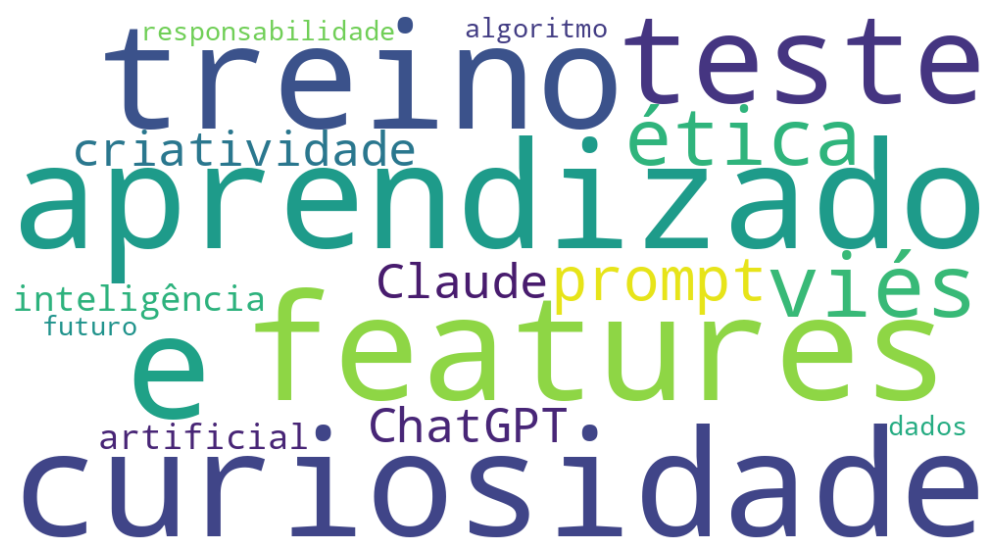

In [8]:
# ✏️ Este exemplo já vem preenchido para demonstração — apague e substitua pelas palavras da turma.

palavras_finais = [
    "aprendizado", "curiosidade", "features",
    "treino e teste", "viés", "ética",
    "prompt", "criatividade", "Claude", "ChatGPT",
    "inteligência artificial", "responsabilidade",
    "dados", "algoritmo", "futuro",
]

from wordcloud import WordCloud
import matplotlib.pyplot as plt

texto = " ".join(palavras_finais)
nuvem = WordCloud(
    width=1000, height=550, background_color="white", colormap="viridis", collocations=False,
).generate(texto)

plt.figure(figsize=(13, 7))
plt.imshow(nuvem, interpolation="bilinear")
plt.axis("off")
plt.show()


---
## ✅ Encerramento da oficina

Ao longo dos 3 encontros, a turma:
- Entendeu os conceitos básicos de IA e construiu um glossário coletivo.
- Aprendeu o que são features e como elas ajudam (humanos e IAs) a tomar decisões.
- Viu, na prática, como um modelo de IA aprende sozinho a partir de exemplos — e por que testamos com dados novos.
- Discutiu vieses, riscos e cuidados no uso da IA, com um exemplo prático de injustiça algorítmica.
- Criou algo autoral, praticando engenharia de prompt com ferramentas reais de IA generativa.

**Obrigado por participar da oficina Mentes Conectadas!** 🧠✨
